# Data fusion for spectroscopic Brix prediction: low-, mid-, and high-level CNN fusion

This notebook compares three strategies for **fusing NIR and Raman spectra** with 1D CNNs to predict strawberry dry matter (Brix), using the paired `NIR_Raman_Strawberry_Brix_prediction.mat` dataset:

1. **Low-level fusion** - concatenate the raw NIR and Raman spectra into a single input vector and train one CNN on top of it.
2. **Mid-level fusion** - give each spectrum its own convolutional branch, then concatenate the learned features before the dense head (a parallel multiblock CNN).
3. **High-level fusion** - train a separate CNN per spectrum and fuse their predictions afterwards, either by simple averaging or by a learned (stacked) linear combination.

Each strategy is trained and evaluated under the same conditions (same calibration / validation / test split, same optimizer schedule) so that the final RMSE / R² numbers are directly comparable.

##  Imports and setup
We import NumPy/Pandas for data handling, Matplotlib for plotting, TensorFlow/Keras for
the CNNs, and the scikit-learn helpers used for splitting the data and scoring the models.
Random seeds are fixed so that the results below are reproducible across reruns.


In [ ]:
# Install some of the necessary packages in google colab
!pip install -q numpy pandas matplotlib tensorflow scikit-learn scipy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Define the path to your data and result folders in Google Drive
# data_path="data"
data_path = '/content/drive/MyDrive/data/data_fusion'

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [39]:
# Shared training configuration
EPOCHS = 300

def make_callbacks(verbose=1):
    """Fresh EarlyStopping + ReduceLROnPlateau callbacks for one training run.

    A new list is returned on every call because Keras callbacks are
    stateful (they track things like the best epoch), so the same instances
    can't be reused safely across separate `model.fit` calls.
    """
    return [
        EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=verbose),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25, min_lr=1e-6, verbose=verbose)
    ]

## Data loading and exploration
The dataset pairs an NIR and a Raman spectrum for every strawberry sample, together with a reference dry matter (Brix) value measured in the lab. It ships pre-split into a calibration set (`_cal`) and a test set (`_test`); we will carve a validation set out of the calibration set later.


In [ ]:
import scipy.io

filename = f"{data_path}/NIR_Raman_Strawberry_Brix_prediction.mat"
data = scipy.io.loadmat(filename)
data.keys()  # Check the keys in the loaded .mat file

dict_keys(['__header__', '__version__', '__globals__', 'X_nir_cal', 'X_nir_test', 'X_raman_cal', 'X_raman_test', 'Y_cal', 'Y_test', 'wl_nir', 'wl_raman'])

### Unpack the arrays
`X_nir_*` and `X_raman_*` hold the spectra (samples × wavelengths), `y_*` holds the reference dry matter values, and `wl_nir` / `wl_raman` hold the wavelength axes used for plotting.


In [41]:
X_nir_train = data['X_nir_cal']
X_nir_test = data['X_nir_test']
X_raman_train = data['X_raman_cal']
X_raman_test = data['X_raman_test']
y_train = data['Y_cal'].ravel()  # Flatten to 1D
y_test = data['Y_test'].ravel()  # Flatten to 1D

In [42]:
raman_wavelengths = data['wl_raman'].ravel()
nir_wavelengths = data['wl_nir'].ravel()

### Data summary and spectral preview
Before training anything, it's worth checking the shapes and looking at a handful of spectra and the target distribution — this is a quick sanity check that the two modalities and the labels line up as expected.


In [43]:
print("--- Dataset shapes ---")
print(f"NIR train/test: {X_nir_train.shape} / {X_nir_test.shape}")
print(f"Raman train/test: {X_raman_train.shape} / {X_raman_test.shape}")
print(f"NIR wavelength range: {nir_wavelengths.min():.1f} nm - {nir_wavelengths.max():.1f} nm")
print(f"Raman wavelength range: {raman_wavelengths.min():.1f} nm - {raman_wavelengths.max():.1f} nm")

y_summary = pd.Series(np.concatenate([y_train, y_test]), name="Dry matter (%)")
print("\n--- Target (dry matter) summary, train + test combined ---")
print(y_summary.describe().round(2))

--- Dataset shapes ---
NIR train/test: (996, 125) / (400, 125)
Raman train/test: (996, 1387) / (400, 1387)
NIR wavelength range: 908.1 nm - 1676.2 nm
Raman wavelength range: 407.0 nm - 1793.0 nm

--- Target (dry matter) summary, train + test combined ---
count    1396.00
mean        9.20
std         1.68
min         3.80
25%         8.00
50%         9.00
75%        10.10
max        15.60
Name: Dry matter (%), dtype: float64


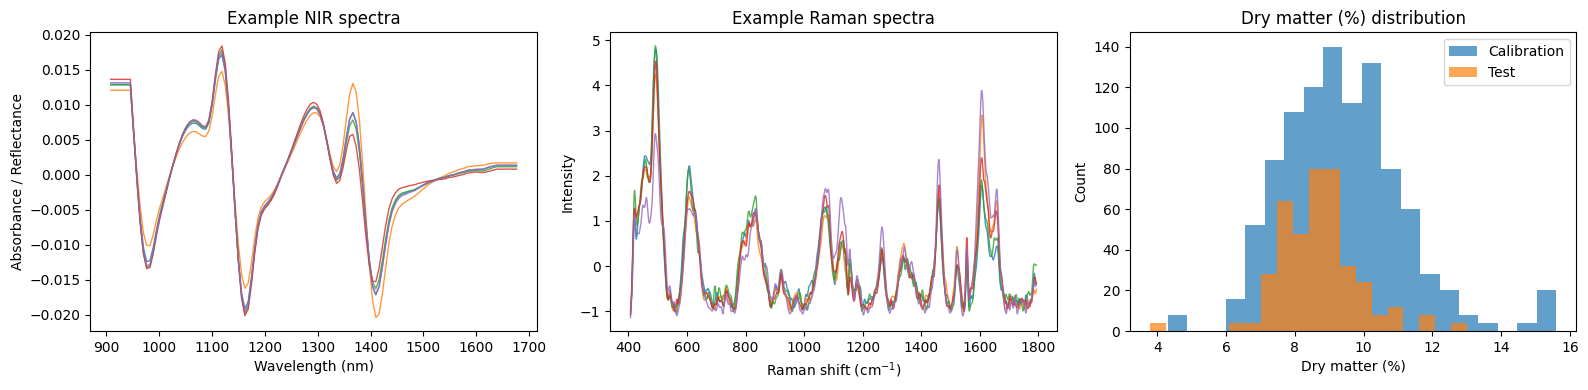

In [44]:
# Preview a few example spectra from each modality, plus the target distribution
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_nir_train.shape[0], size=5, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i in sample_idx:
    axes[0].plot(nir_wavelengths, X_nir_train[i], linewidth=1, alpha=0.8)
axes[0].set_title("Example NIR spectra")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Absorbance / Reflectance")

for i in sample_idx:
    axes[1].plot(raman_wavelengths, X_raman_train[i], linewidth=1, alpha=0.8)
axes[1].set_title("Example Raman spectra")
axes[1].set_xlabel("Raman shift (cm$^{-1}$)")
axes[1].set_ylabel("Intensity")

axes[2].hist(y_train, bins=20, alpha=0.7, label="Calibration")
axes[2].hist(y_test, bins=20, alpha=0.7, label="Test")
axes[2].set_title("Dry matter (%) distribution")
axes[2].set_xlabel("Dry matter (%)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()


### Calibration / validation / test split
The calibration set is further split into calibration and validation subsets (66.66% / 33.33%), keeping the two modalities aligned sample-for-sample. The test set is left untouched until final evaluation.

Both spectra are then standardized (zero mean, unit variance per wavelength) with a `StandardScaler` fit on the calibration set only, and applied unchanged to every fusion strategy below - so low-, mid-, and high-level fusion all see the same preprocessed inputs.


In [45]:
# Further split train into Calibration and Validation (66.66% / 33.33%)
X_raman_cal, X_raman_val, X_nir_cal, X_nir_val, y_cal, y_val = train_test_split(
    X_raman_train, X_nir_train, y_train, test_size=0.33, random_state=42
)

print(f"Calibration set: {X_raman_cal.shape[0]} samples")
print(f"Validation set:  {X_raman_val.shape[0]} samples")
print(f"Test set:        {X_raman_test.shape[0]} samples")

Calibration set: 667 samples
Validation set:  329 samples
Test set:        400 samples


In [46]:
# Standardize both modalities (zero mean, unit variance per wavelength).
# Scalers are fit on the calibration set only and then applied to the
# validation and test sets, to avoid leaking information from those splits.
# This scaling is applied once, here, so every fusion strategy below - low-,
# mid-, and high-level - trains and evaluates on identically preprocessed
# spectra instead of each method doing its own ad-hoc preprocessing.
raman_scaler = StandardScaler()
X_raman_cal = raman_scaler.fit_transform(X_raman_cal)
X_raman_val = raman_scaler.transform(X_raman_val)
X_raman_test = raman_scaler.transform(X_raman_test)

nir_scaler = StandardScaler()
X_nir_cal = nir_scaler.fit_transform(X_nir_cal)
X_nir_val = nir_scaler.transform(X_nir_val)
X_nir_test = nir_scaler.transform(X_nir_test)

## Low-level fusion: single-block CNN
The simplest fusion strategy: concatenate the NIR and Raman spectra end-to-end into one long vector and let a single CNN learn from the combined input. This is a useful benchmark - it tells us how much the architecture of mid-level fusion adds on top of just handing the model more numbers.


In [47]:
L2_BETA = 0.003
RAMAN_FILTER_SIZE = 5
NIR_FILTER_SIZE = 30
BATCH_SIZE = 32

initial_lr = 0.01 * (BATCH_SIZE / 256)

Concatenate the two spectra along the wavelength axis for each split.


In [48]:
# Concatenate Raman and NIR along the wavelength axis
X_single_train = np.concatenate([X_raman_cal, X_nir_cal], axis=1)
X_single_val = np.concatenate([X_raman_val, X_nir_val], axis=1)
X_single_test = np.concatenate([X_raman_test, X_nir_test], axis=1)

Two 1D convolutional layers (kernel size 25, a compromise between the Raman and NIR filter sizes used later) followed by a small dense head predict the single dry-matter output.


In [49]:
# Single Block Model (using a compromise filter size of 25, as mentioned in the paper)
single_input = Input(shape=(len(raman_wavelengths) + len(nir_wavelengths), 1), name='single_input')
x_single = Conv1D(filters=1, kernel_size=25, strides=1, activation='elu', kernel_regularizer=l2(L2_BETA))(single_input)
x_single = Conv1D(filters=1, kernel_size=25, strides=1, activation='elu', kernel_regularizer=l2(L2_BETA))(x_single)
x_single_flat = Flatten()(x_single)

x_single_dense = Dense(36, activation='elu', kernel_regularizer=l2(L2_BETA))(x_single_flat)
x_single_dense = Dense(18, activation='elu', kernel_regularizer=l2(L2_BETA))(x_single_dense)
x_single_dense = Dense(12, activation='elu', kernel_regularizer=l2(L2_BETA))(x_single_dense)
single_output = Dense(1, activation='linear')(x_single_dense)

single_model = Model(inputs=single_input, outputs=single_output, name='Single_Block_CNN')
single_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr), loss='mse')

Train with the shared callbacks (early stopping on the validation loss, plus learning-rate reduction on a plateau) used for every fusion strategy in this notebook.


In [50]:
print("Training Single-Block Benchmark Model...")
single_history = single_model.fit(
    x=X_single_train, y=y_cal,
    validation_data=(X_single_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)

Training Single-Block Benchmark Model...
Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 25.7209 - val_loss: 3.8952 - learning_rate: 0.0012
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.6134 - val_loss: 2.9773 - learning_rate: 0.0012
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9935 - val_loss: 2.6906 - learning_rate: 0.0012
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5386 - val_loss: 2.1241 - learning_rate: 0.0012
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2448 - val_loss: 1.8120 - learning_rate: 0.0012
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0618 - val_loss: 1.6647 - learning_rate: 0.0012
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9382 - val_loss: 1.6030 - learning_rate: 0.0012
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8481 - val_loss: 1.5707 - learning_rate: 0.0012
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7759 - val_loss: 1

Evaluate on the held-out test set.


In [51]:
# Evaluate Single Block
y_test_pred_low_fusion = single_model.predict(X_single_test)
rmse_low_fusion = np.sqrt(mean_squared_error(y_test, y_test_pred_low_fusion))
r2_low_fusion = r2_score(y_test, y_test_pred_low_fusion)

print(f"\n--- Single-Block CNN Test Performance ---")
print(f"RMSE: {rmse_low_fusion:.3f} % DM")
print(f"R²:   {r2_low_fusion:.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

--- Single-Block CNN Test Performance ---
RMSE: 0.934 % DM
R²:   0.404


## Mid-level fusion: parallel multiblock CNN
Instead of concatenating raw spectra, each modality gets its own convolutional branch so the network can learn modality-specific features (a small filter for the narrow Raman peaks, a larger filter for the broader NIR bands). The two feature vectors are then concatenated and passed through a shared dense head. Hyperparameters are re-declared here so this section is self-contained.


In [52]:
L2_BETA = 0.003
RAMAN_FILTER_SIZE = 5
NIR_FILTER_SIZE = 30
BATCH_SIZE = 32

###  Raman branch


In [53]:
# Raman Branch
raman_input = Input(shape=(len(raman_wavelengths), 1), name='raman_input')
x_raman = Conv1D(filters=1, kernel_size=RAMAN_FILTER_SIZE, strides=1, 
                 activation='elu', kernel_regularizer=l2(L2_BETA), name='raman_conv1')(raman_input)
x_raman = Conv1D(filters=1, kernel_size=RAMAN_FILTER_SIZE, strides=1, 
                 activation='elu', kernel_regularizer=l2(L2_BETA), name='raman_conv2')(x_raman)
x_raman_flat = Flatten(name='raman_flatten')(x_raman)

### NIR branch


In [54]:
# Near-Infrared Branch
nir_input = Input(shape=(len(nir_wavelengths), 1), name='nir_input')
x_nir = Conv1D(filters=1, kernel_size=NIR_FILTER_SIZE, strides=1, 
               activation='elu', kernel_regularizer=l2(L2_BETA), name='nir_conv1')(nir_input)
x_nir = Conv1D(filters=1, kernel_size=NIR_FILTER_SIZE, strides=1, 
               activation='elu', kernel_regularizer=l2(L2_BETA), name='nir_conv2')(x_nir)
x_nir_flat = Flatten(name='nir_flatten')(x_nir)

### Fusion layer and dense head
The two branches' flattened feature maps are concatenated before the shared dense layers.


In [55]:
# Merge and append dense layers
merged = Concatenate(name='fusion_concat')([x_raman_flat, x_nir_flat])
x_dense = Dense(36, activation='elu', kernel_regularizer=l2(L2_BETA))(merged)
x_dense = Dense(18, activation='elu', kernel_regularizer=l2(L2_BETA))(x_dense)
x_dense = Dense(12, activation='elu', kernel_regularizer=l2(L2_BETA))(x_dense)
output = Dense(1, activation='linear', name='output')(x_dense)

### Build and compile the model
The learning rate follows the paper's scaling rule (`0.01 * batch_size / 256`).


In [56]:
# Build Model
model = Model(inputs=[raman_input, nir_input], outputs=output, name='Parallel_Multiblock_CNN')

# Compile Model
# Note: Paper uses Adam with LR = 0.01 * (batch_size / 256)
initial_lr = 0.01 * (BATCH_SIZE / 256)
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(optimizer=optimizer, loss='mse')
model.summary()

Model: "Parallel_Multiblock_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raman_input         │ (None, 1387, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nir_input           │ (None, 125, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raman_conv1         │ (None, 1383, 1)   │          6 │ raman_input[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nir_conv1 (Conv1D)  │ (None, 96, 1)     │         31 │ nir_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raman_conv2         │ (None, 1379, 1)   │          6 │ raman_conv1[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nir_conv2 (Conv1D)  │ (None, 67, 1)     │         31 │ nir_conv1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raman_flatten       │ (None, 1379)      │          0 │ raman_conv2[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nir_flatten         │ (None, 67)        │          0 │ nir_conv2[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 1446)      │          0 │ raman_flatten[0]… │
│ (Concatenate)       │                   │            │ nir_flatten[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 36)        │     52,092 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 18)        │        666 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 12)        │        228 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         13 │ dense_17[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,073 (207.32 KB)

 Trainable params: 53,073 (207.32 KB)

 Non-trainable params: 0 (0.00 B)

### Training callbacks
Early stopping guards against overfitting; reducing the learning rate on a validation-loss plateau helps the model fine-tune once progress slows down. These are the same shared callbacks (`make_callbacks()`) used for every fusion strategy in this notebook.


In [57]:
callbacks = make_callbacks()

### Train the model


In [58]:
history = model.fit(
    x={'raman_input': X_raman_cal, 'nir_input': X_nir_cal},
    y=y_cal,
    validation_data=({'raman_input': X_raman_val, 'nir_input': X_nir_val}, y_val),
    epochs=300, # Max epochs (EarlyStopping will likely halt this earlier)
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 53.1589 - val_loss: 4.1338 - learning_rate: 0.0012
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.0600 - val_loss: 2.5403 - learning_rate: 0.0012
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6201 - val_loss: 1.2250 - learning_rate: 0.0012
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1819 - val_loss: 1.1949 - learning_rate: 0.0012
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0164 - val_loss: 1.1053 - learning_rate: 0.0012
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9278 - val_loss: 1.0645 - learning_rate: 0.0012
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8666 - val_loss: 1.0317 - learning_rate: 0.0012
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8174 - val_loss: 1.0083 - learning_rate: 0.0012
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7779 - val_loss: 0.9896 - learning_rate: 0.0012
Epoch 10/300
21/

### Training curves


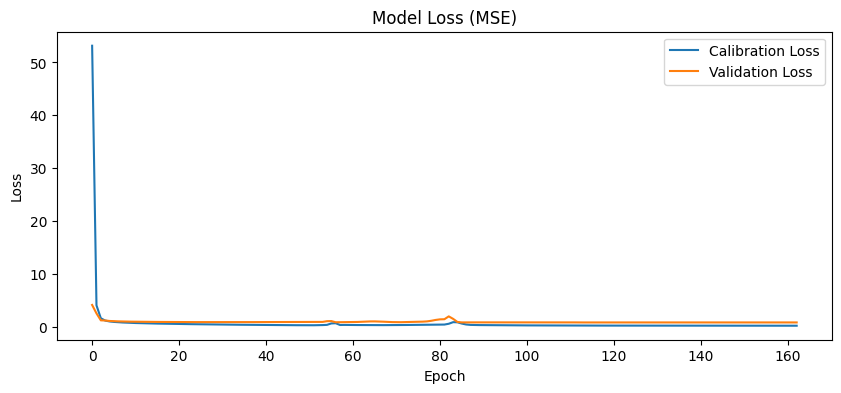

In [59]:
# Plot Training History
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Calibration Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Evaluate on the independent test set


In [60]:
# Predict on Test Set
y_test_pred_mid_fusion = model.predict({'raman_input': X_raman_test, 'nir_input': X_nir_test})

# Calculate Metrics
rmse_mid_fusion = np.sqrt(mean_squared_error(y_test, y_test_pred_mid_fusion))
r2_mid_fusion = r2_score(y_test, y_test_pred_mid_fusion)


print(f"\n--- Test Set Performance ---")
print(f"RMSE: {rmse_mid_fusion:.3f} % DM")
print(f"R²:   {r2_mid_fusion:.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

--- Test Set Performance ---
RMSE: 0.855 % DM
R²:   0.500


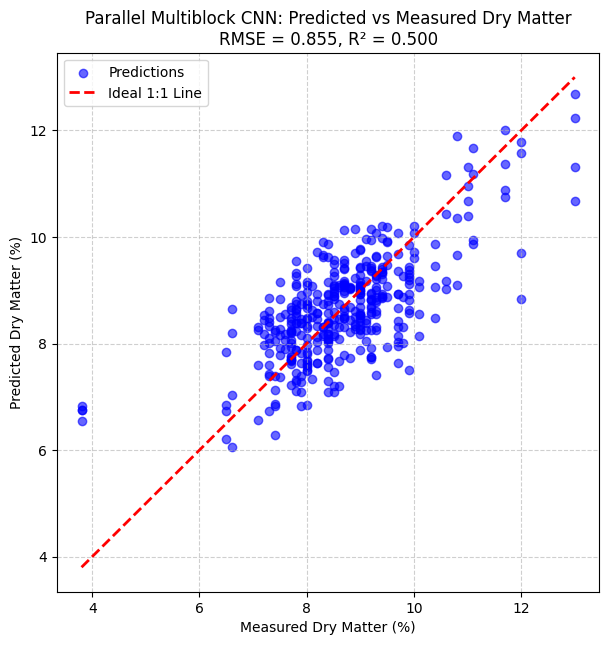

In [61]:
# Plot Predictions vs Actuals
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred_mid_fusion, alpha=0.6, color='blue', label='Predictions')

# Add 1:1 line
min_val = min(np.min(y_test), np.min(y_test_pred_mid_fusion))
max_val = max(np.max(y_test), np.max(y_test_pred_mid_fusion))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')

plt.title(f'Parallel Multiblock CNN: Predicted vs Measured Dry Matter\nRMSE = {rmse_mid_fusion:.3f}, R² = {r2_mid_fusion:.3f}')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## High-level fusion: separate models with a fused decision
Here the two modalities are never mixed inside a network at all: a Raman-only CNN and an NIR-only CNN are trained independently, and their *predictions* are combined afterwards. This tests whether fusing decisions late is competitive with fusing features earlier.

### Raman-only CNN
Same convolutional design as the Raman branch above, trained end-to-end on its own.


In [62]:
raman_model_input = Input(shape=(len(raman_wavelengths), 1), name='raman_input_hl')
x_raman_hl = Conv1D(filters=1, kernel_size=RAMAN_FILTER_SIZE, strides=1, 
                    activation='elu', kernel_regularizer=l2(L2_BETA))(raman_model_input)
x_raman_hl = Conv1D(filters=1, kernel_size=RAMAN_FILTER_SIZE, strides=1, 
                    activation='elu', kernel_regularizer=l2(L2_BETA))(x_raman_hl)
x_raman_hl_flat = Flatten()(x_raman_hl)
x_raman_hl_dense = Dense(36, activation='elu', kernel_regularizer=l2(L2_BETA))(x_raman_hl_flat)
x_raman_hl_dense = Dense(18, activation='elu', kernel_regularizer=l2(L2_BETA))(x_raman_hl_dense)
raman_output = Dense(1, activation='linear', name='raman_output')(x_raman_hl_dense)

raman_only_model = Model(inputs=raman_model_input, outputs=raman_output, name='Raman_Only_CNN')
raman_only_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr), loss='mse')

In [63]:
print("\nTraining Raman-Only Model...")
history_raman = raman_only_model.fit(
    x=X_raman_cal, y=y_cal,
    validation_data=(X_raman_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)


Training Raman-Only Model...
Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 17.8819 - val_loss: 5.1426 - learning_rate: 0.0012
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5074 - val_loss: 3.6061 - learning_rate: 0.0012
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6631 - val_loss: 2.6971 - learning_rate: 0.0012
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1295 - val_loss: 2.4400 - learning_rate: 0.0012
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7571 - val_loss: 2.2661 - learning_rate: 0.0012
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.5063 - val_loss: 2.1429 - learning_rate: 0.0012
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3161 - val_loss: 2.0661 - learning_rate: 0.0012
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1749 - val_loss: 2.0130 - learning_rate: 0.0012
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0638 - val_loss: 1.9677 - learn

### NIR-only CNN
Both modalities were already standardized above (see the calibration/validation/test split section), so the NIR-only model here uses the same scaled arrays as everywhere else in the notebook - no separate preprocessing step. The model itself uses more filters per layer, since it no longer has a Raman branch to lean on.


In [64]:
nir_model_input = Input(shape=(len(nir_wavelengths), 1), name='nir_input_hl')
x_nir_hl = Conv1D(filters=8, kernel_size=NIR_FILTER_SIZE, strides=1,
                   activation='elu', kernel_regularizer=l2(L2_BETA))(nir_model_input)
x_nir_hl = Conv1D(filters=4, kernel_size=NIR_FILTER_SIZE, strides=1,
                   activation='elu', kernel_regularizer=l2(L2_BETA))(x_nir_hl)
x_nir_hl_flat = Flatten()(x_nir_hl)
x_nir_hl_dense = Dense(36, activation='elu', kernel_regularizer=l2(L2_BETA))(x_nir_hl_flat)
x_nir_hl_dense = Dense(18, activation='elu', kernel_regularizer=l2(L2_BETA))(x_nir_hl_dense)
nir_output = Dense(1, activation='linear', name='nir_output')(x_nir_hl_dense)

nir_only_model = Model(inputs=nir_model_input, outputs=nir_output, name='NIR_Only_CNN')
nir_only_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr), loss='mse')

In [65]:
print("Training NIR-Only Model...")
history_nir = nir_only_model.fit(
    x=X_nir_cal, y=y_cal,
    validation_data=(X_nir_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)

Training NIR-Only Model...
Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 51.1656 - val_loss: 19.9062 - learning_rate: 0.0012
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.5948 - val_loss: 5.5506 - learning_rate: 0.0012
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0855 - val_loss: 2.3695 - learning_rate: 0.0012
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8614 - val_loss: 1.5250 - learning_rate: 0.0012
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3865 - val_loss: 1.2559 - learning_rate: 0.0012
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2160 - val_loss: 1.0932 - learning_rate: 0.0012
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0927 - val_loss: 1.0187 - learning_rate: 0.0012
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0052 - val_loss: 0.9638 - learning_rate: 0.0012
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9354 - val_loss: 0.9214 - learning_r

### Compare training curves


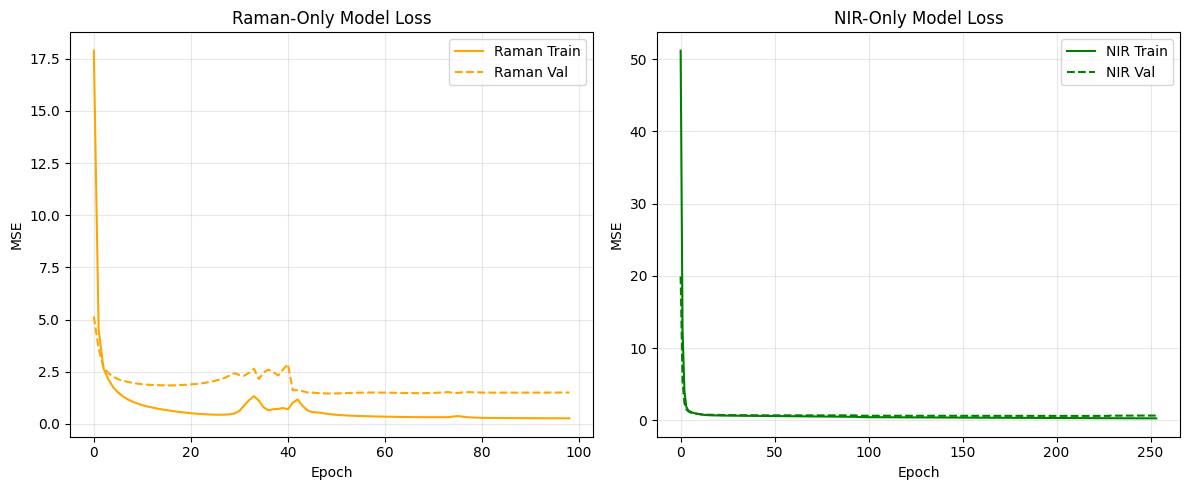

In [66]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_raman.history['loss'], label='Raman Train', color='orange')
plt.plot(history_raman.history['val_loss'], label='Raman Val', color='orange', linestyle='--')
plt.title('Raman-Only Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_nir.history['loss'], label='NIR Train', color='green')
plt.plot(history_nir.history['val_loss'], label='NIR Val', color='green', linestyle='--')
plt.title('NIR-Only Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Generate predictions from each base model
Validation-set predictions are needed to *fit* the fusion strategies below; test-set
predictions are needed to *evaluate* them.


In [67]:
# Validation set predictions (used for determining fusion weights)
y_val_pred_raman = raman_only_model.predict(X_raman_val, verbose=0).ravel()
y_val_pred_nir = nir_only_model.predict(X_nir_val, verbose=0).ravel()

# Test set predictions
y_test_pred_raman = raman_only_model.predict(X_raman_test, verbose=0).ravel()
y_test_pred_nir = nir_only_model.predict(X_nir_test, verbose=0).ravel()

In [68]:
# Evaluate individual models on test set
rmse_raman = np.sqrt(mean_squared_error(y_test, y_test_pred_raman))
r2_raman = r2_score(y_test, y_test_pred_raman)

rmse_nir = np.sqrt(mean_squared_error(y_test, y_test_pred_nir))
r2_nir = r2_score(y_test, y_test_pred_nir)
print("\n--- Individual Models Test Performance ---")
print(f"Raman-Only CNN -> RMSE: {rmse_raman:.3f}, R²: {r2_raman:.3f}")
print(f"NIR-Only CNN   -> RMSE: {rmse_nir:.3f}, R²: {r2_nir:.3f}")


--- Individual Models Test Performance ---
Raman-Only CNN -> RMSE: 1.064, R²: 0.228
NIR-Only CNN   -> RMSE: 0.798, R²: 0.566


### Fusing the decisions
Two fusion strategies are compared: an unweighted average of the two predictions, and a weighted average learned with a linear regression meta-learner (stacking) fit on the validation-set predictions.

In [69]:
# Strategy 1: simple averaging
y_test_pred_simple_avg = (y_test_pred_raman + y_test_pred_nir) / 2.0

rmse_simple_avg = np.sqrt(mean_squared_error(y_test, y_test_pred_simple_avg))
r2_simple_avg = r2_score(y_test, y_test_pred_simple_avg)

print(f"High-Level Fusion: Simple Averaging")
print(f"RMSE:{rmse_simple_avg:.3f} % DM")
print(f"R²:{r2_simple_avg:.3f}")

High-Level Fusion: Simple Averaging
RMSE:0.736 % DM
R²:0.630


In [70]:
#  Weighted averaging via Linear Regression Meta-Learner
from sklearn.linear_model import LinearRegression

y_train_pred_raman = raman_only_model.predict(X_raman_cal, verbose=0).ravel()
y_train_pred_nir = nir_only_model.predict(X_nir_cal, verbose=0).ravel()

X_train_meta = np.column_stack((y_train_pred_raman, y_train_pred_nir))
meta_learner = LinearRegression()
meta_learner.fit(X_train_meta, y_cal)

# The learned weights (coefficients) show how much each model is "voted" for
print(f"\nMeta-learner weights (Raman, NIR): {meta_learner.coef_}")
print(f"Meta-learner intercept: {meta_learner.intercept_:.3f}")


Meta-learner weights (Raman, NIR): [0.46922305 0.5507717 ]
Meta-learner intercept: -0.205


In [71]:
# Apply meta-learner to test set predictions
X_test_meta = np.column_stack((y_test_pred_raman, y_test_pred_nir))
y_test_pred_weighted = meta_learner.predict(X_test_meta)

rmse_weighted = np.sqrt(mean_squared_error(y_test, y_test_pred_weighted))
r2_weighted = r2_score(y_test, y_test_pred_weighted)

print(f"\n--- High-Level Fusion: Weighted Averaging (Stacking) ---")
print(f"RMSE: {rmse_weighted:.3f} % DM")
print(f"R²:   {r2_weighted:.3f}")


--- High-Level Fusion: Weighted Averaging (Stacking) ---
RMSE: 0.716 % DM
R²:   0.650


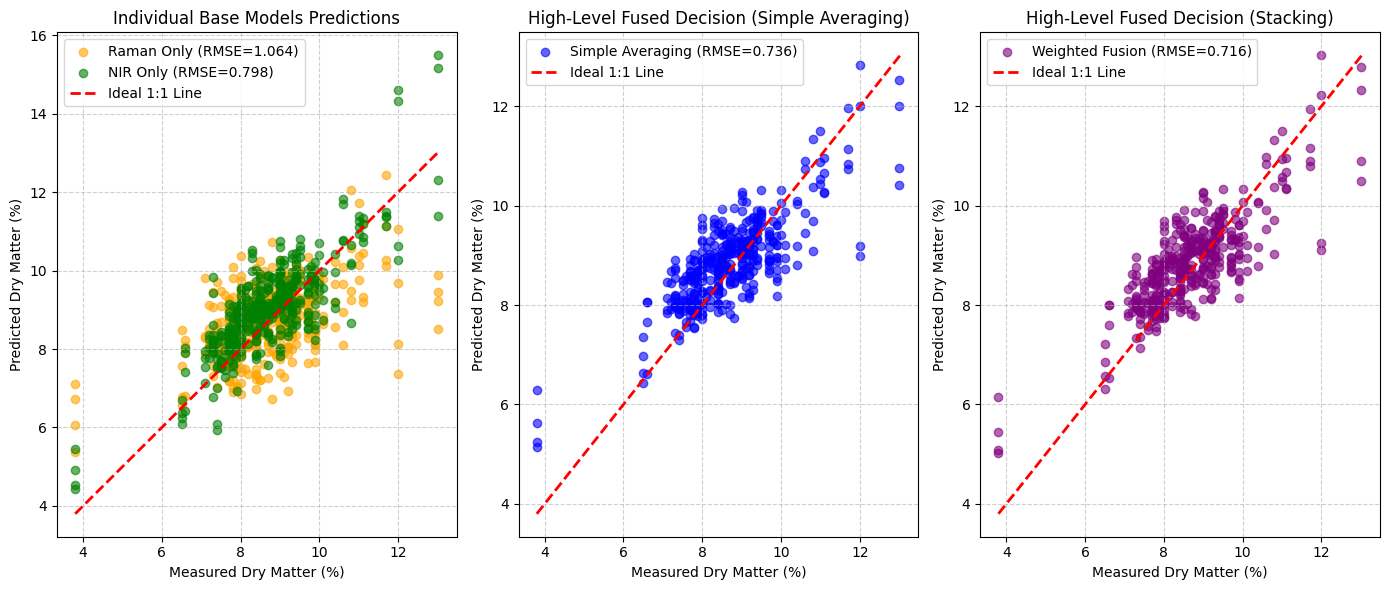

In [72]:
# Plot predictions vs actual values for high-level fusion
min_val = min(np.min(y_test), np.min(y_test_pred_weighted))
max_val = max(np.max(y_test), np.max(y_test_pred_weighted))

plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_test_pred_raman, alpha=0.6, color='orange', label=f'Raman Only (RMSE={rmse_raman:.3f})')
plt.scatter(y_test, y_test_pred_nir, alpha=0.6, color='green', label=f'NIR Only (RMSE={rmse_nir:.3f})')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('Individual Base Models Predictions')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_test_pred_simple_avg, alpha=0.6, color='blue', label=f'Simple Averaging (RMSE={rmse_simple_avg:.3f})')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('High-Level Fused Decision (Simple Averaging)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_test_pred_weighted, alpha=0.6, color='purple', label=f'Weighted Fusion (RMSE={rmse_weighted:.3f})')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('High-Level Fused Decision (Stacking)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Final comparison of all fusion strategies


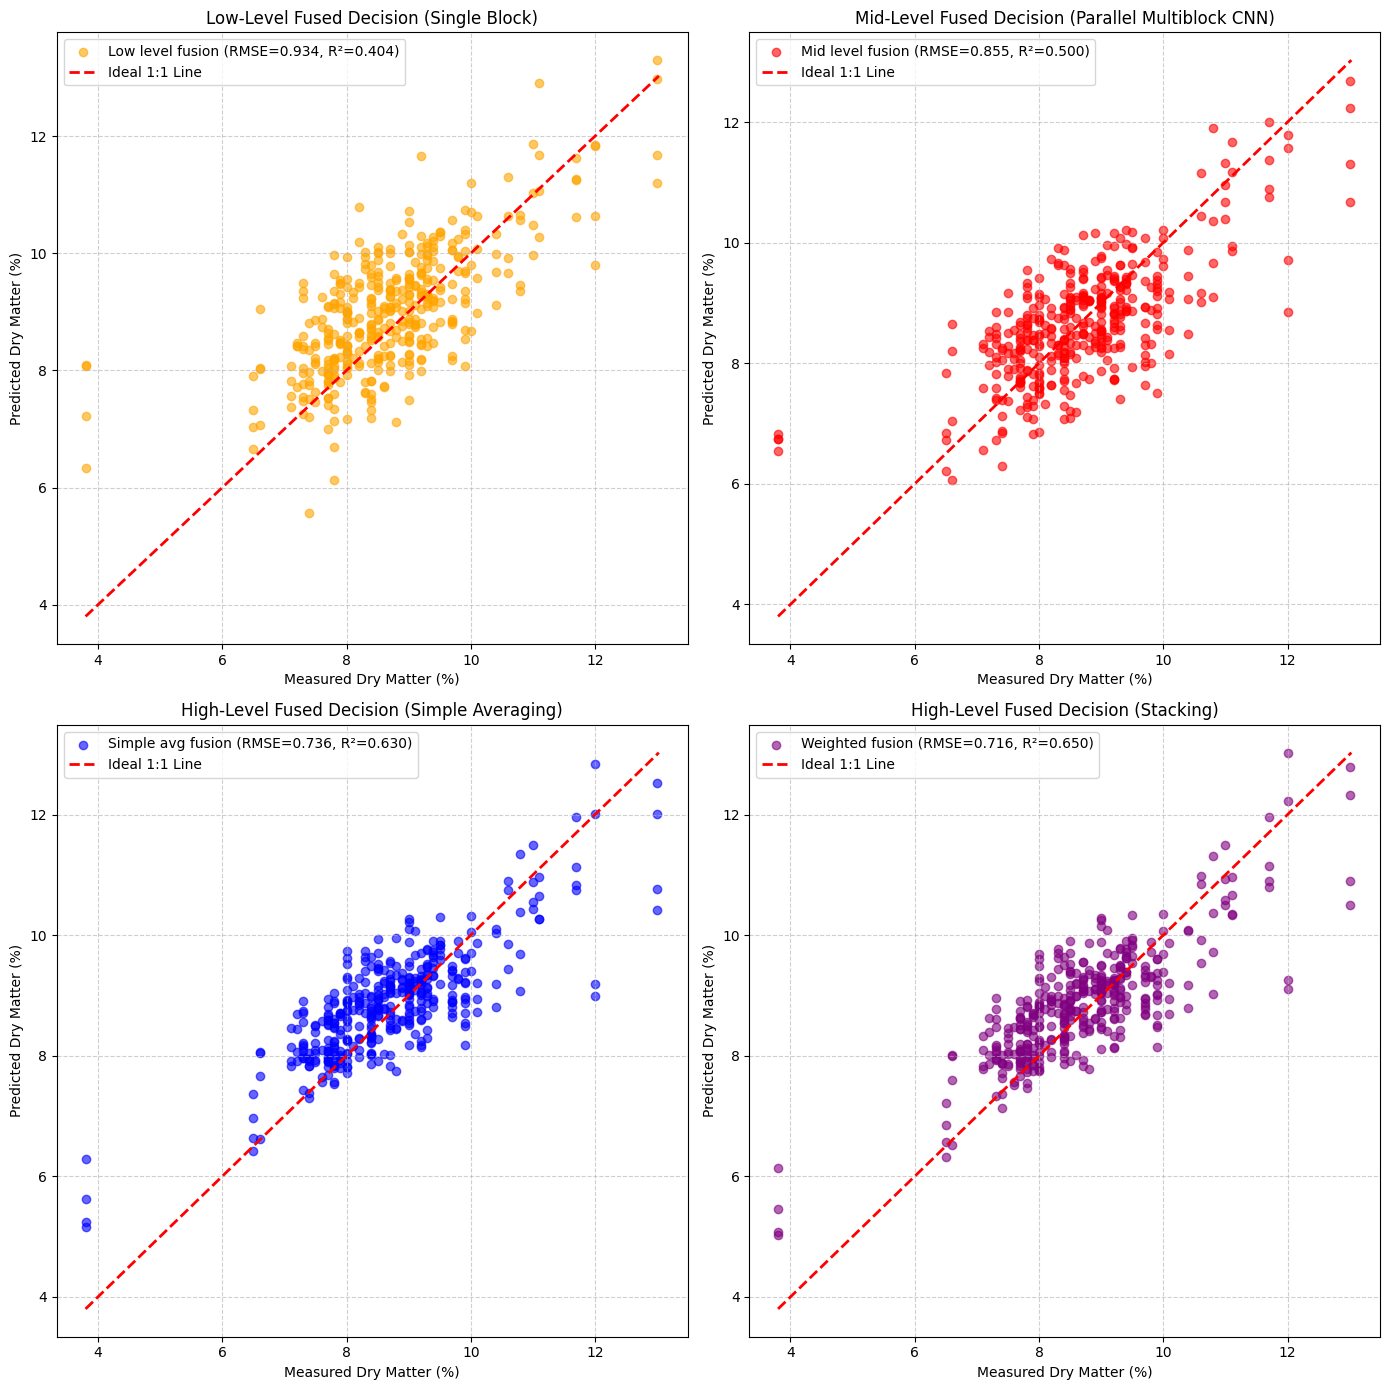

In [73]:
# Show prediction results for all approaches
plt.figure(figsize=(14, 14))

plt.subplot(2, 2, 1)
plt.scatter(y_test, y_test_pred_low_fusion, alpha=0.6, color='orange', label=f'Low level fusion (RMSE={rmse_low_fusion:.3f}, R²={r2_low_fusion:.3f})')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('Low-Level Fused Decision (Single Block)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 2, 2)
plt.scatter(y_test, y_test_pred_mid_fusion, alpha=0.6, color='red', label=f'Mid level fusion (RMSE={rmse_mid_fusion:.3f}, R²={r2_mid_fusion:.3f})')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('Mid-Level Fused Decision (Parallel Multiblock CNN)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 2, 3)
plt.scatter(y_test, y_test_pred_simple_avg, alpha=0.6, color='blue', label=f'Simple avg fusion (RMSE={rmse_simple_avg:.3f}, R²={r2_simple_avg:.3f})')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('High-Level Fused Decision (Simple Averaging)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 2, 4)
plt.scatter(y_test, y_test_pred_weighted, alpha=0.6, color='purple', label=f'Weighted fusion (RMSE={rmse_weighted:.3f}, R²={r2_weighted:.3f})')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('High-Level Fused Decision (Stacking)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [74]:
# Final comparison of all approaches
print("FINAL COMPARISON OF ALL FUSION STRATEGIES")
print(f"1. Single-Block (Low-Level) RMSE: {rmse_low_fusion:.3f}")
print(f"2. Parallel Multiblock (Mid-Level) RMSE: {rmse_mid_fusion:.3f}")
print(f"3. Raman-Only (High-Level Base) RMSE: {rmse_raman:.3f}")
print(f"4. NIR-Only (High-Level Base) RMSE: {rmse_nir:.3f}")
print(f"5. High-Level Fusion (Simple Avg) RMSE: {rmse_simple_avg:.3f}")
print(f"6. High-Level Fusion (Weighted) RMSE: {rmse_weighted:.3f}")
print("="*55)
print(f"1. Single-Block (Low-Level) R²: {r2_low_fusion:.3f}")
print(f"2. Parallel Multiblock (Mid-Level) R²: {r2_mid_fusion:.3f}")
print(f"3. Raman-Only (High-Level Base) R²: {r2_raman:.3f}")
print(f"4. NIR-Only (High-Level Base) R²: {r2_nir:.3f}")
print(f"5. High-Level Fusion (Simple Avg) R²: {r2_simple_avg:.3f}")
print(f"6. High-Level Fusion (Weighted) R²: {r2_weighted:.3f}")

FINAL COMPARISON OF ALL FUSION STRATEGIES
1. Single-Block (Low-Level) RMSE: 0.934
2. Parallel Multiblock (Mid-Level) RMSE: 0.855
3. Raman-Only (High-Level Base) RMSE: 1.064
4. NIR-Only (High-Level Base) RMSE: 0.798
5. High-Level Fusion (Simple Avg) RMSE: 0.736
6. High-Level Fusion (Weighted) RMSE: 0.716
1. Single-Block (Low-Level) R²: 0.404
2. Parallel Multiblock (Mid-Level) R²: 0.500
3. Raman-Only (High-Level Base) R²: 0.228
4. NIR-Only (High-Level Base) R²: 0.566
5. High-Level Fusion (Simple Avg) R²: 0.630
6. High-Level Fusion (Weighted) R²: 0.650


### Takeaways
- **Low-level fusion** is the simplest to implement but gives the network the least structure to exploit - it has to learn everything from a single concatenated vector.
- **Mid-level fusion** lets each modality contribute specialized features before they are combined, which usually captures complementary information better than either the low-level or high-level approach.
- **High-level fusion** is the most modular (each model can be trained, tuned, or swapped independently), and you have a choice in how to combine the results from each modality.